# Árvores de Decisão

## Atividade Prática



In [1]:
import pandas as pd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score


### Abra o dataset disponível no endereço abaixo, verifique seu número de linhas e colunas, e a distribuição dos valores da coluna genre

### https://www.kaggle.com/adityaraut/spotify-dataset-predict-using-decisiontree

In [ ]:
df = pd.read_csv('../../datasets/spotify.csv')
df.head()

,danceability,energy,key,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,genre,song_name
0,0.831,0.814,2,-7.364,0.4200,0.0598,0.013400,0.0556,0.3890,156.985,124539,Dark Trap,Mercury: Retrograde
1,0.719,0.493,8,-7.230,0.0794,0.4010,0.000000,0.1180,0.1240,115.080,224427,Dark Trap,Pathology
2,0.850,0.893,5,-4.783,0.0623,0.0138,0.000004,0.3720,0.0391,218.050,98821,Dark Trap,Symbiote
3,0.476,0.781,0,-4.710,0.1030,0.0237,0.000000,0.1140,0.1750,186.948,123661,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote)
4,0.798,0.624,2,-7.668,0.2930,0.2170,0.000000,0.1660,0.5910,147.988,123298,Dark Trap,Venom


In [3]:
df.shape

(42305, 13)

In [4]:
df['genre'].unique()

array(['Dark Trap', 'Underground Rap', 'Trap Metal', 'Emo', 'Rap', 'RnB',
       'Pop', 'Hiphop', 'techhouse', 'techno', 'trance', 'psytrance',
       'trap', 'dnb', 'hardstyle'], dtype=object)

In [5]:
df.groupby(['genre']).size()

genre
Dark Trap          4578
Emo                1680
Hiphop             3028
Pop                 461
Rap                1848
RnB                2099
Trap Metal         1956
Underground Rap    5875
dnb                2966
hardstyle          2936
psytrance          2961
techhouse          2975
techno             2956
trance             2999
trap               2987
dtype: int64

<AxesSubplot:xlabel='genre'>

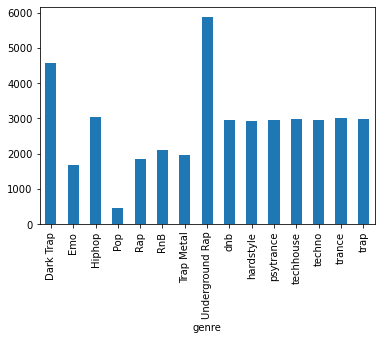

In [6]:
df.groupby(['genre']).size().plot(kind='bar')

### Através de atributos como danceability, energy e loudness, é possível classificar uma música pelo seu estilo, como Pop, Techno e Rap, entre outros. Explore esse dataset, treine árvores de decisão e realize o tuning de hiperparâmetros através de GridSearchCV. Sua meta é conseguir uma precisão de, no mínimo, 65%, tanto no conjunto de treinamento quanto no conjunto de teste.

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(['genre', 'song_name'], axis=1)
Y = df['genre']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=True)

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier().fit(x_train, y_train)

In [9]:
y_pred = dt_model.predict(x_test)

In [10]:
pred_results = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

In [11]:
pred_results.head()

,y_test,y_pred
17919,RnB,RnB
29649,trance,techno
8869,Underground Rap,Underground Rap
34795,trap,trap
34575,trap,trap


In [12]:
df_crosstab = pd.crosstab(pred_results.y_pred, pred_results.y_test)
df_crosstab

y_test,Dark Trap,Emo,Hiphop,Pop,Rap,RnB,Trap Metal,Underground Rap,dnb,hardstyle,psytrance,techhouse,techno,trance,trap
y_pred,,,,,,,,,,,,,,,
Dark Trap,348,18,60,10,45,37,123,262,3,21,8,11,10,44,29
Emo,21,168,20,12,4,38,7,19,6,14,0,3,0,6,10
Hiphop,61,18,178,14,44,127,18,215,6,2,0,3,1,5,2
Pop,7,20,9,14,1,20,2,8,1,0,0,1,0,3,0
Rap,24,4,48,5,152,19,7,122,0,1,0,0,0,0,1
RnB,32,24,79,13,26,108,5,62,2,2,0,2,1,0,3
Trap Metal,120,13,14,3,9,8,84,137,2,7,0,2,0,9,12
Underground Rap,187,16,158,12,91,67,123,294,4,6,0,5,0,1,17
dnb,9,11,4,0,1,1,0,4,555,0,0,0,0,0,0


In [13]:
dt_model.get_depth()

35

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.5738092424063349
Precisão :  0.5738092424063349
Recall :  0.5738092424063349


In [15]:
from sklearn import preprocessing
onehotencoder = preprocessing.OneHotEncoder()

Y = np.asarray(df['genre']).reshape(-1, 1)
onehotencoder.fit(Y)

onehotlabels = onehotencoder.transform(Y).toarray()
onehotlabels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, onehotlabels, test_size=0.2)

In [17]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier().fit(x_train, y_train)

In [18]:
y_pred = dt_model.predict(x_test)

In [19]:
dt_model.get_depth()

34

In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.5654177993145019
Precisão :  0.6101262594056881
Recall :  0.5654177993145019


In [21]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]}

grid_search = GridSearchCV(DecisionTreeClassifier(), parameters, cv=3, return_train_score=True)
grid_search.fit(x_train, y_train)

grid_search.best_params_

{'max_depth': 16}

In [22]:
for i in range(15):
    print('Parameters: ', grid_search.cv_results_['params'][i])
    print('Mean Test Score: ', grid_search.cv_results_['mean_test_score'][i])
    print('Rank: ', grid_search.cv_results_['rank_test_score'][i])

Parameters:  {'max_depth': 2}
Mean Test Score:  0.11830761704242365
Rank:  15
Parameters:  {'max_depth': 3}
Mean Test Score:  0.18478911005066867
Rank:  13
Parameters:  {'max_depth': 4}
Mean Test Score:  0.1777863157309667
Rank:  14
Parameters:  {'max_depth': 5}
Mean Test Score:  0.36476220007187427
Rank:  12
Parameters:  {'max_depth': 6}
Mean Test Score:  0.38506079222941114
Rank:  11
Parameters:  {'max_depth': 7}
Mean Test Score:  0.42435741015703954
Rank:  10
Parameters:  {'max_depth': 8}
Mean Test Score:  0.47296422263072885
Rank:  9
Parameters:  {'max_depth': 9}
Mean Test Score:  0.4797011904606819
Rank:  8
Parameters:  {'max_depth': 10}
Mean Test Score:  0.5070614743053451
Rank:  7
Parameters:  {'max_depth': 11}
Mean Test Score:  0.5151574501741445
Rank:  6
Parameters:  {'max_depth': 12}
Mean Test Score:  0.5252627748947803
Rank:  5
Parameters:  {'max_depth': 13}
Mean Test Score:  0.5361361644486994
Rank:  4
Parameters:  {'max_depth': 14}
Mean Test Score:  0.546743837513289
Rank:

In [23]:
dt_model = DecisionTreeClassifier(max_depth = grid_search.best_params_['max_depth']).fit(x_train, y_train)

In [24]:
y_pred = dt_model.predict(x_test)

In [25]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.5641177165819643
Precisão :  0.6810787671232876
Recall :  0.5641177165819643


In [26]:
from sklearn import tree
text_representation = tree.export_text(dt_model)
print(text_representation)

|--- feature_10 <= 343692.00
|   |--- feature_1 <= 0.83
|   |   |--- feature_6 <= 0.04
|   |   |   |--- feature_10 <= 192942.50
|   |   |   |   |--- feature_9 <= 103.04
|   |   |   |   |   |--- feature_0 <= 0.43
|   |   |   |   |   |   |--- feature_8 <= 0.41
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- feature_8 >  0.41
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- feature_0 >  0.43
|   |   |   |   |   |   |--- feature_7 <= 0.35
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- feature_7 >  0.35
|   |   |   |   |   |   |   |--- feature_7 <= 0.37
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- feature_7 >  0.37
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_9 >  103.04
|   |   |   |   |   |--- feature_0 <= 0.71
|   |   |   |   |   |   |--- feature_4 <= 0.11
|   |   |   |   |   |   |   |--- feature_10 <= 169165.50
|   |   |   |   |   |   |   |   |--- feature_1 <=

In [27]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], \
             'max_features': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}

grid_search = GridSearchCV(DecisionTreeClassifier(), parameters, cv=3, return_train_score=True)
grid_search.fit(x_train, y_train)

grid_search.best_params_

{'max_depth': 16, 'max_features': 11}

In [28]:
for i in range(15):
    print('Parameters: ', grid_search.cv_results_['params'][i])
    print('Mean Test Score: ', grid_search.cv_results_['mean_test_score'][i])
    print('Rank: ', grid_search.cv_results_['rank_test_score'][i])

Parameters:  {'max_depth': 2, 'max_features': 2}
Mean Test Score:  0.0542766505205432
Rank:  146
Parameters:  {'max_depth': 2, 'max_features': 3}
Mean Test Score:  0.0
Rank:  150
Parameters:  {'max_depth': 2, 'max_features': 4}
Mean Test Score:  0.03179269836387419
Rank:  148
Parameters:  {'max_depth': 2, 'max_features': 5}
Mean Test Score:  0.07038277835947919
Rank:  144
Parameters:  {'max_depth': 2, 'max_features': 6}
Mean Test Score:  0.07496225558227641
Rank:  143
Parameters:  {'max_depth': 2, 'max_features': 7}
Mean Test Score:  0.06600728905731594
Rank:  145
Parameters:  {'max_depth': 2, 'max_features': 8}
Mean Test Score:  0.0966192324429496
Rank:  140
Parameters:  {'max_depth': 2, 'max_features': 9}
Mean Test Score:  0.07838798816791488
Rank:  142
Parameters:  {'max_depth': 2, 'max_features': 10}
Mean Test Score:  0.11830761704242365
Rank:  137
Parameters:  {'max_depth': 2, 'max_features': 11}
Mean Test Score:  0.11830761704242365
Rank:  137
Parameters:  {'max_depth': 3, 'max_f

In [29]:
dt_model = DecisionTreeClassifier(max_depth = grid_search.best_params_['max_depth'], \
                                 max_features = grid_search.best_params_['max_features']).fit(x_train, y_train)

In [30]:
y_pred = dt_model.predict(x_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.5610447937596029
Precisão :  0.6790158775568588
Recall :  0.5610447937596029


In [32]:
from sklearn.model_selection import GridSearchCV

parameters = {'criterion': ['gini', 'entropy'], \
              'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], \
              'max_features': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}

grid_search = GridSearchCV(DecisionTreeClassifier(), parameters, cv=3, return_train_score=True)
grid_search.fit(x_train, y_train)

grid_search.best_params_

{'criterion': 'entropy', 'max_depth': 16, 'max_features': 10}

In [33]:
for i in range(15):
    print('Parameters: ', grid_search.cv_results_['params'][i])
    print('Mean Test Score: ', grid_search.cv_results_['mean_test_score'][i])
    print('Rank: ', grid_search.cv_results_['rank_test_score'][i])

Parameters:  {'criterion': 'gini', 'max_depth': 2, 'max_features': 2}
Mean Test Score:  0.05740876055806942
Rank:  286
Parameters:  {'criterion': 'gini', 'max_depth': 2, 'max_features': 3}
Mean Test Score:  0.03994917708240995
Rank:  292
Parameters:  {'criterion': 'gini', 'max_depth': 2, 'max_features': 4}
Mean Test Score:  0.003575333156044086
Rank:  298
Parameters:  {'criterion': 'gini', 'max_depth': 2, 'max_features': 5}
Mean Test Score:  0.073041622068699
Rank:  280
Parameters:  {'criterion': 'gini', 'max_depth': 2, 'max_features': 6}
Mean Test Score:  0.11830761704242365
Rank:  269
Parameters:  {'criterion': 'gini', 'max_depth': 2, 'max_features': 7}
Mean Test Score:  0.05806062304352796
Rank:  285
Parameters:  {'criterion': 'gini', 'max_depth': 2, 'max_features': 8}
Mean Test Score:  0.06600728905731594
Rank:  282
Parameters:  {'criterion': 'gini', 'max_depth': 2, 'max_features': 9}
Mean Test Score:  0.09029591595209478
Rank:  277
Parameters:  {'criterion': 'gini', 'max_depth': 2

In [34]:
dt_model = DecisionTreeClassifier(criterion = grid_search.best_params_['criterion'], \
                                  max_depth = grid_search.best_params_['max_depth'], \
                                  max_features = grid_search.best_params_['max_features']).fit(x_train, y_train)

In [35]:
y_pred = dt_model.predict(x_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.5691998581727928
Precisão :  0.6532826912642431
Recall :  0.5691998581727928
